In [1]:
import os
import json
import random
import pickle
import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


2026-05-10 18:08:07.125623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778436487.328633      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778436487.390015      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778436487.862234      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778436487.862274      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778436487.862276      23 computation_placer.cc:177] computation placer alr

In [2]:
SEEDS = [42, 123, 2024, 3407, 777]

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
IMAGE_SIZE = (256, 256)
AUTOTUNE = tf.data.AUTOTUNE

EXPERIMENT_NAME = "CustomLightweightCNN"


In [3]:
DATASET_DIR = "/kaggle/input/datasets/faysalmiah1721758/potato-dataset"


In [4]:
class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES = len(class_names)

print("Dataset directory:", DATASET_DIR)
print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", NUM_CLASSES)


Dataset directory: /kaggle/input/datasets/faysalmiah1721758/potato-dataset
Detected classes:
0: Potato___Early_blight
1: Potato___Late_blight
2: Potato___healthy
Number of classes: 3


In [5]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(valid_extensions):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for idx, count in zip(unique, counts):
    print(f"{class_names[idx]}: {count}")


Total images: 2152

Class distribution:
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152


In [6]:
def load_dataset_cnn(file_paths, labels, augment=False, shuffle=True, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=0.1)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            image = tf.clip_by_value(image, 0.0, 1.0)

        label = tf.one_hot(label, depth=NUM_CLASSES)

        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(file_paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


In [7]:
def build_custom_lightweight_cnn(num_classes, input_shape=(256, 256, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="CustomLightweightCNN")

    return model


In [8]:
def count_model_parameters(model):
    total_params = model.count_params()

    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])

    non_trainable_params = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params


In [9]:
def run_single_seed(seed):
    print("\n" + "=" * 70)
    print(f"Running seed: {seed}")
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_temp, y_train, y_temp = train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=seed
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed
    )

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    class_weight_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )
    class_weight = dict(enumerate(class_weight_vals))
    print("Class weights:", class_weight)

    train_ds = load_dataset_cnn(X_train, y_train, augment=True, shuffle=True, seed=seed)
    val_ds = load_dataset_cnn(X_val, y_val, augment=False, shuffle=False, seed=seed)
    test_ds = load_dataset_cnn(X_test, y_test, augment=False, shuffle=False, seed=seed)

    model = build_custom_lightweight_cnn(num_classes=NUM_CLASSES)

    total_params, trainable_params, non_trainable_params = count_model_parameters(model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)
    os.makedirs("reports", exist_ok=True)

    run_name = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_seed_{seed}"

    model_path = f"models/{run_name}.keras"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_accuracy_loss.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"
    report_path = f"reports/{run_name}_classification_report.json"

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    stopped_epoch = len(history.history["loss"])
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []

    for images, batch_labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    with open(report_path, "w") as f:
        json.dump(report_dict, f, indent=4)

    print(f"\nSeed {seed} Test Accuracy: {test_acc:.4f}")
    print(f"Seed {seed} Test Loss: {test_loss:.4f}")
    print(f"Seed {seed} Stopped Epoch: {stopped_epoch}")
    print(f"Seed {seed} Best Epoch: {best_epoch}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix - Seed {seed}")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    result = {
        "seed": seed,
        "num_classes": NUM_CLASSES,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "stopped_epoch": stopped_epoch,
        "best_epoch": best_epoch,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "model_path": model_path,
        "history_path": history_path,
        "plot_path": plot_path,
        "confusion_matrix_path": cm_path,
        "classification_report_path": report_path
    }

    return result



Running seed: 42
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}


I0000 00:00:1778436513.829092      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total parameters: 380,739
Trainable parameters: 380,739
Non-trainable parameters: 0.0
Epoch 1/50


I0000 00:00:1778436521.969542      65 service.cc:152] XLA service 0x7f3ea4210d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778436521.969587      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778436522.505871      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4688 - loss: 1.0023 

I0000 00:00:1778436527.496240      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 0.4956 - loss: 1.0513 - val_accuracy: 0.5302 - val_loss: 0.8024
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6016 - loss: 0.6706 - val_accuracy: 0.6744 - val_loss: 0.6452
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7224 - loss: 0.4455 - val_accuracy: 0.7907 - val_loss: 0.4368
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8274 - loss: 0.3185 - val_accuracy: 0.9209 - val_loss: 0.2280
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8921 - loss: 0.2233 - val_accuracy: 0.8698 - val_loss: 0.3233
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8927 - loss: 0.2174 - val_accuracy: 0.8698 - val_loss: 0.3048
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9104 - loss: 0.1807 - val_accuracy: 0.9628 - val_loss: 0.1145
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9576 - loss: 0.0887 - val_accuracy: 0.9070 - val_loss: 

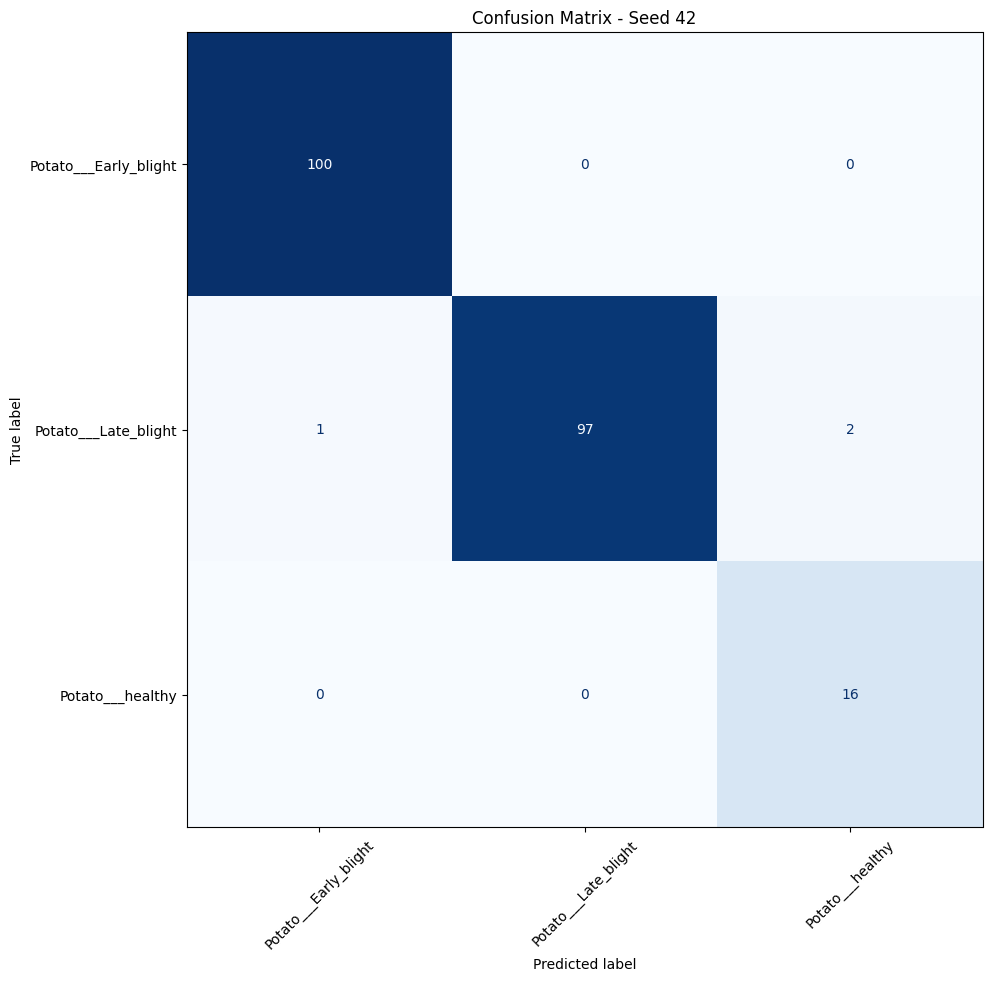

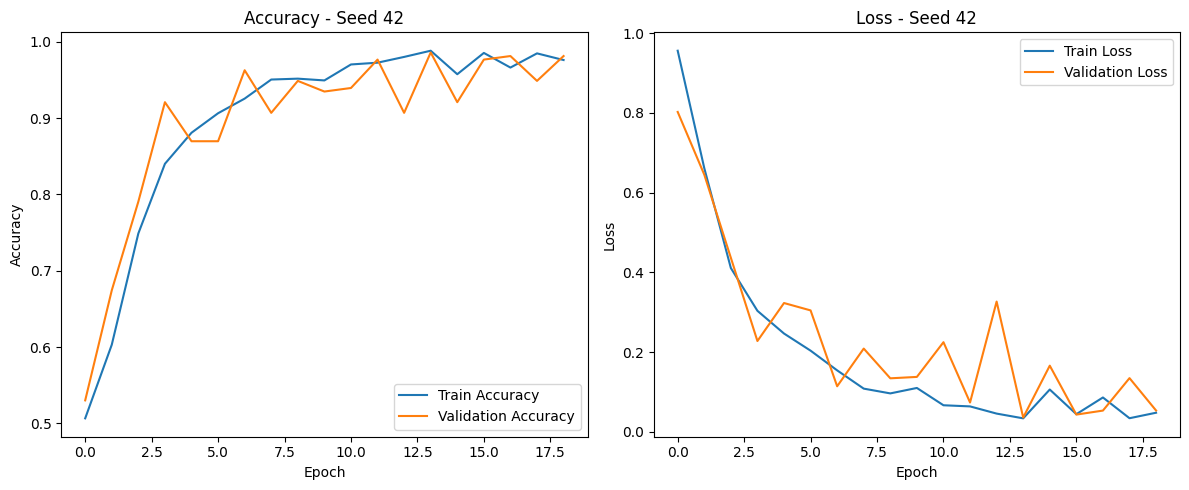


Running seed: 123
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Total parameters: 380,739
Trainable parameters: 380,739
Non-trainable parameters: 0.0
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.4011 - loss: 1.0852 - val_accuracy: 0.6512 - val_loss: 0.9033
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.6165 - loss: 0.7498 - val_accuracy: 0.6930 - val_loss: 0.5890
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7356 - loss: 0.4431 - val_accuracy: 0.7488 - val_loss: 0.4887
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8425 - loss: 0.3212 - val_accuracy: 0.8419 - val_loss: 0.3627
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8654 - loss: 0.2621 - val_accuracy: 0.8977 - val_loss: 0.2226
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9294 - loss: 0.1644 - val_accuracy:

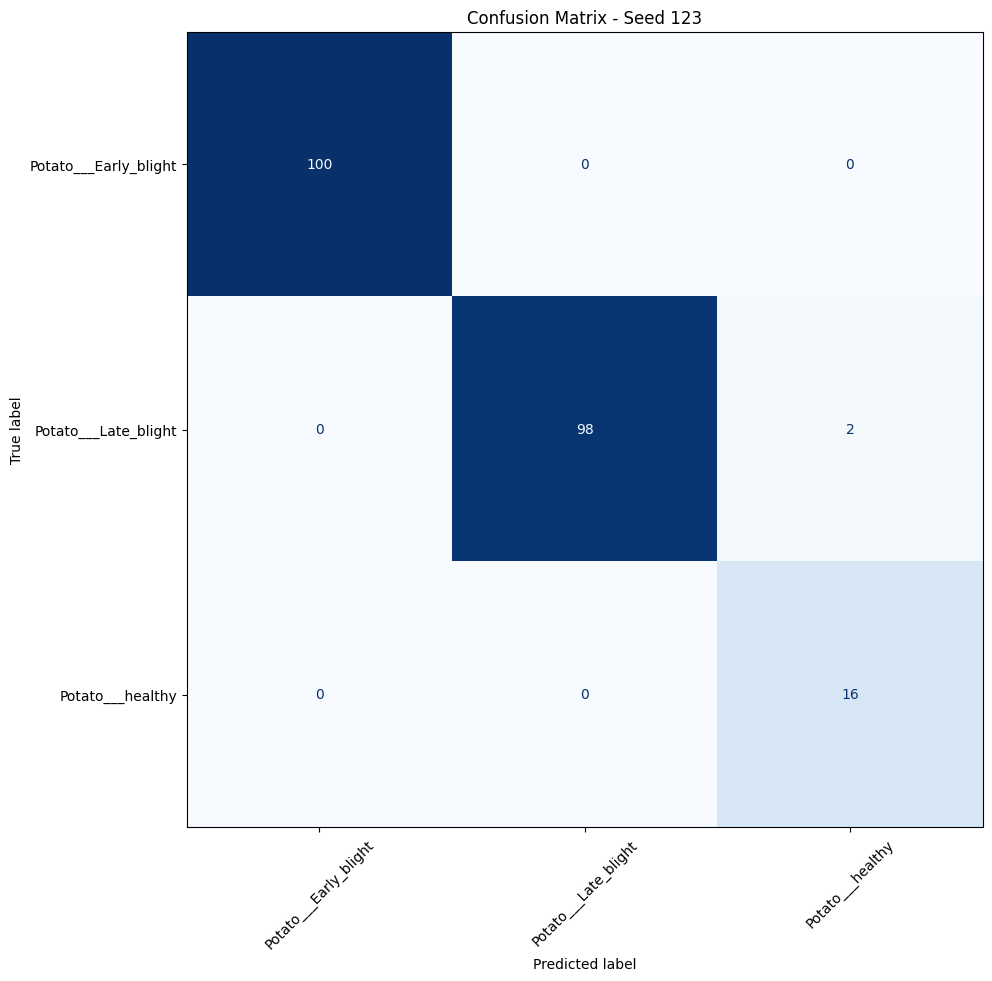

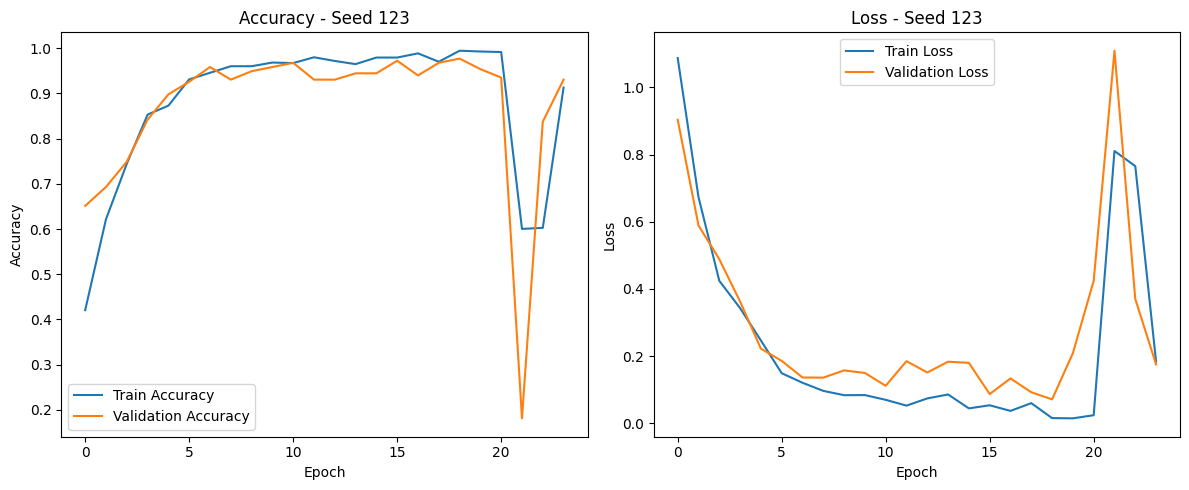


Running seed: 2024
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Total parameters: 380,739
Trainable parameters: 380,739
Non-trainable parameters: 0.0
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.3950 - loss: 1.0928 - val_accuracy: 0.0698 - val_loss: 1.1166
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4891 - loss: 1.0107 - val_accuracy: 0.5349 - val_loss: 0.7381
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5583 - loss: 0.7138 - val_accuracy: 0.5953 - val_loss: 0.7293
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6733 - loss: 0.6262 - val_accuracy: 0.7163 - val_loss: 0.6633
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7901 - loss: 0.3842 - val_accuracy: 0.7814 - val_loss: 0.4530
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8512 - loss: 0.2986 - val_accuracy

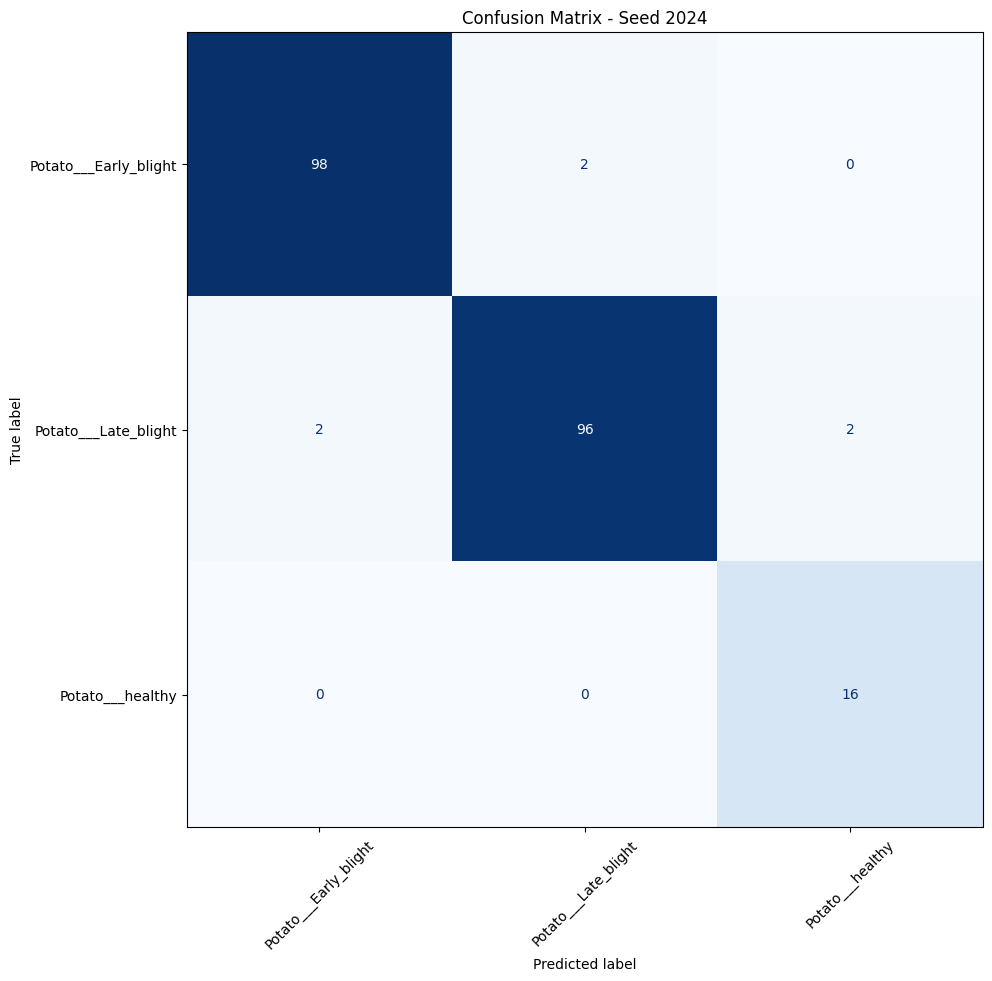

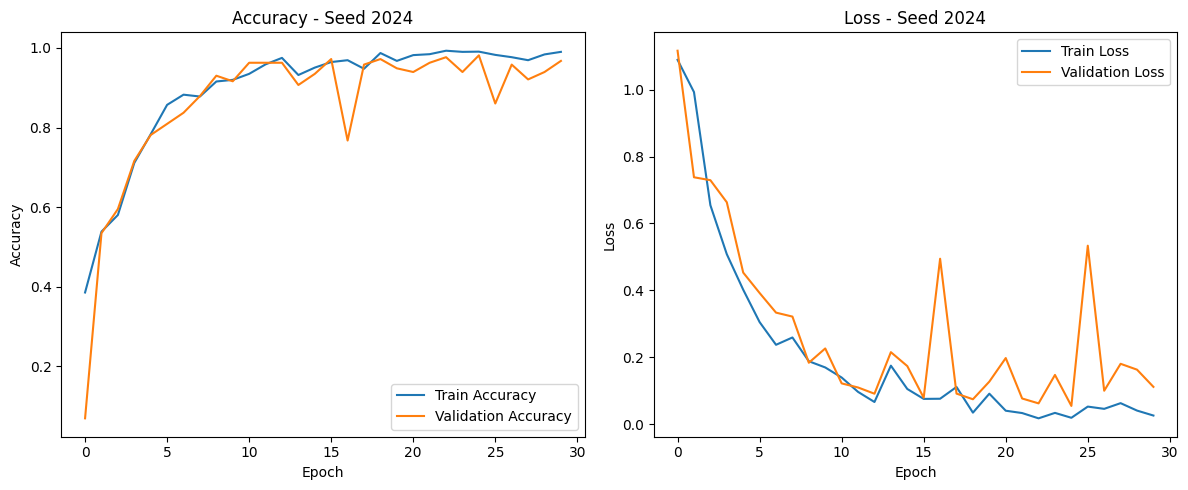


Running seed: 3407
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Total parameters: 380,739
Trainable parameters: 380,739
Non-trainable parameters: 0.0
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.5313 - loss: 1.0305 - val_accuracy: 0.4605 - val_loss: 1.2208
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4897 - loss: 0.8161 - val_accuracy: 0.6930 - val_loss: 0.7433
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.7912 - loss: 0.3670 - val_accuracy: 0.8233 - val_loss: 0.4971
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8637 - loss: 0.2709 - val_accuracy: 0.8233 - val_loss: 0.4184
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8654 - loss: 0.2719 - val_accuracy: 0.7302 - val_loss: 0.6822
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8814 - loss: 0.2501 - val_accuracy

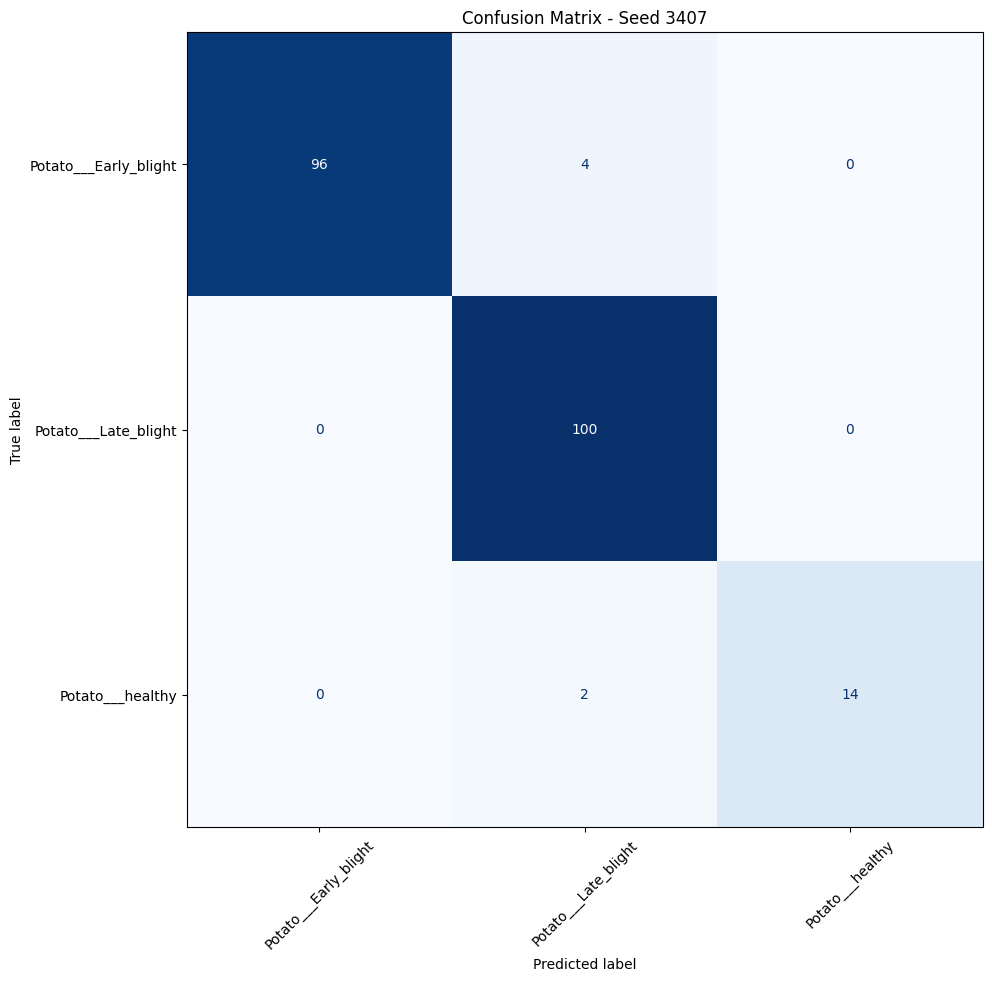

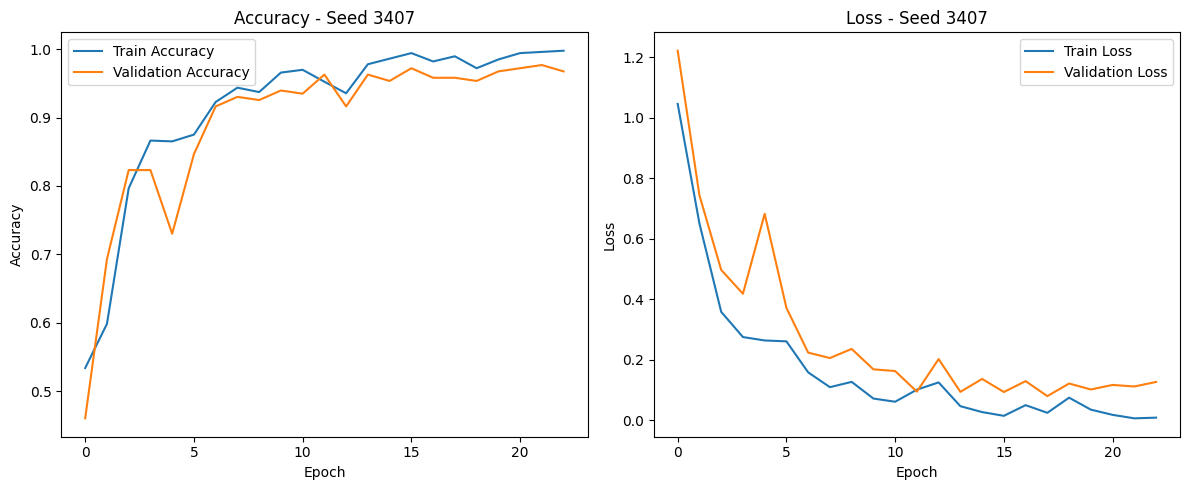


Running seed: 777
Train: 1721
Validation: 215
Test: 216
Class weights: {0: np.float64(0.7170833333333333), 1: np.float64(0.7170833333333333), 2: np.float64(4.741046831955923)}
Total parameters: 380,739
Trainable parameters: 380,739
Non-trainable parameters: 0.0
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.4059 - loss: 1.0835 - val_accuracy: 0.0698 - val_loss: 1.1141
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2058 - loss: 1.1009 - val_accuracy: 0.3535 - val_loss: 1.0954
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.5140 - loss: 1.0026 - val_accuracy: 0.7442 - val_loss: 0.7309
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7135 - loss: 0.8178 - val_accuracy: 0.3442 - val_loss: 1.4029
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6325 - loss: 0.7568 - val_accuracy: 0.6047 - val_loss: 0.7173
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8246 - loss: 0.3880 - val_accuracy:

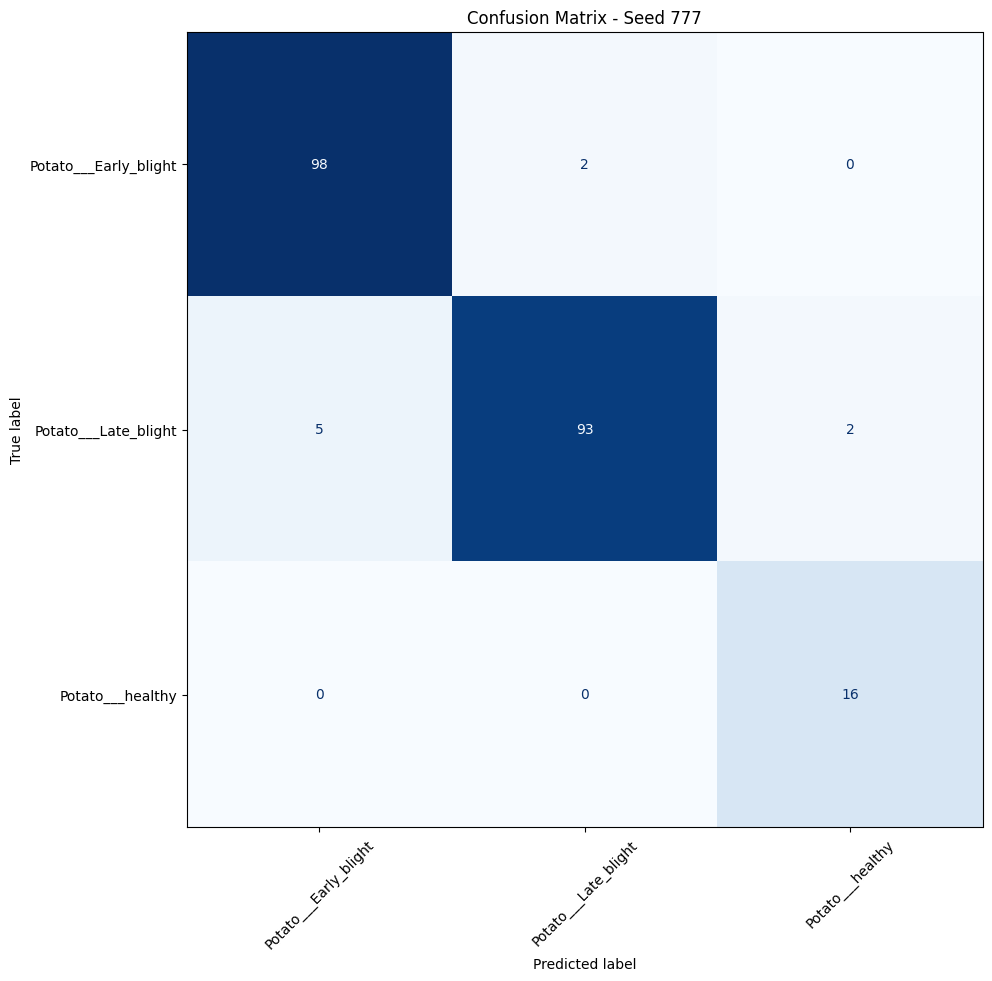

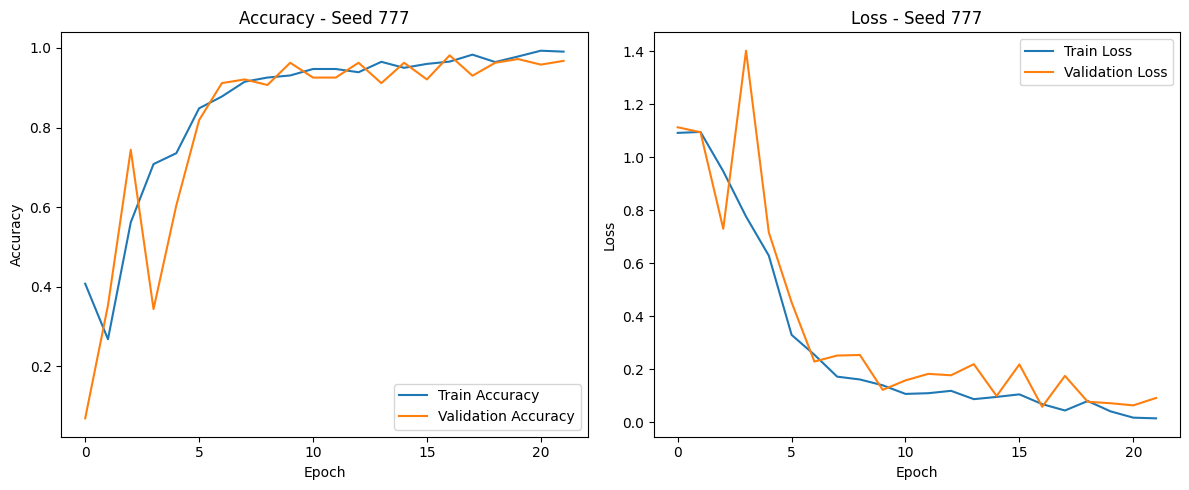


All seed results:
{'seed': 42, 'num_classes': 3, 'test_accuracy': 0.9861111044883728, 'test_loss': 0.027969082817435265, 'stopped_epoch': 19, 'best_epoch': 14, 'macro_precision': 0.9596626329299597, 'macro_recall': 0.9899999999999999, 'macro_f1': 0.9736576399380622, 'weighted_precision': 0.9871857556125984, 'weighted_recall': 0.9861111111111112, 'weighted_f1': 0.9862892057963282, 'total_params': 380739, 'trainable_params': np.int64(380739), 'non_trainable_params': np.float64(0.0), 'model_path': 'models/CustomLightweightCNN_3class_seed_42.keras', 'history_path': 'history/CustomLightweightCNN_3class_seed_42_history.pkl', 'plot_path': 'history/CustomLightweightCNN_3class_seed_42_accuracy_loss.png', 'confusion_matrix_path': 'history/CustomLightweightCNN_3class_seed_42_confusion_matrix.png', 'classification_report_path': 'reports/CustomLightweightCNN_3class_seed_42_classification_report.json'}
{'seed': 123, 'num_classes': 3, 'test_accuracy': 0.9907407164573669, 'test_loss': 0.0245573632419

In [10]:
all_results = []

for seed in SEEDS:
    result = run_single_seed(seed)
    all_results.append(result)

print("\nAll seed results:")
for result in all_results:
    print(result)


In [11]:
accuracies = np.array([result["test_accuracy"] for result in all_results])
losses = np.array([result["test_loss"] for result in all_results])

print("\nMulti-seed summary")
print("=" * 70)
print(f"Mean accuracy: {np.mean(accuracies):.4f}")
print(f"Standard deviation accuracy: {np.std(accuracies):.4f}")
print(f"Mean loss: {np.mean(losses):.4f}")
print(f"Standard deviation loss: {np.std(losses):.4f}")



Multi-seed summary
Mean accuracy: 0.9759
Standard deviation accuracy: 0.0115
Mean loss: 0.0711
Standard deviation loss: 0.0546


In [12]:
results_df = pd.DataFrame(all_results)

csv_path = f"{EXPERIMENT_NAME}_{NUM_CLASSES}class_multiseed_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved results to:", csv_path)
results_df


Saved results to: CustomLightweightCNN_3class_multiseed_results.csv


,seed,num_classes,test_accuracy,test_loss,stopped_epoch,best_epoch,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,total_params,trainable_params,non_trainable_params,model_path,history_path,plot_path,confusion_matrix_path,classification_report_path
0,42,3,0.986111,0.027969,19,14,0.959663,0.990000,0.973658,0.987186,0.986111,0.986289,380739,380739,0.0,models/CustomLightweightCNN_3class_seed_42.keras,history/CustomLightweightCNN_3class_seed_42_hi...,history/CustomLightweightCNN_3class_seed_42_ac...,history/CustomLightweightCNN_3class_seed_42_co...,reports/CustomLightweightCNN_3class_seed_42_cl...
1,123,3,0.990741,0.024557,24,19,0.962963,0.993333,0.977025,0.991770,0.990741,0.990966,380739,380739,0.0,models/CustomLightweightCNN_3class_seed_123.keras,history/CustomLightweightCNN_3class_seed_123_h...,history/CustomLightweightCNN_3class_seed_123_a...,history/CustomLightweightCNN_3class_seed_123_c...,reports/CustomLightweightCNN_3class_seed_123_c...
2,2024,3,0.972222,0.034703,30,25,0.949494,0.980000,0.963624,0.973062,0.972222,0.972354,380739,380739,0.0,models/CustomLightweightCNN_3class_seed_2024.k...,history/CustomLightweightCNN_3class_seed_2024_...,history/CustomLightweightCNN_3class_seed_2024_...,history/CustomLightweightCNN_3class_seed_2024_...,reports/CustomLightweightCNN_3class_seed_2024_...
3,3407,3,0.972222,0.162312,23,18,0.981132,0.945000,0.961266,0.973795,0.972222,0.972129,380739,380739,0.0,models/CustomLightweightCNN_3class_seed_3407.k...,history/CustomLightweightCNN_3class_seed_3407_...,history/CustomLightweightCNN_3class_seed_3407_...,history/CustomLightweightCNN_3class_seed_3407_...,reports/CustomLightweightCNN_3class_seed_3407_...
4,777,3,0.958333,0.106208,22,17,0.939764,0.970000,0.953513,0.959549,0.958333,0.958311,380739,380739,0.0,models/CustomLightweightCNN_3class_seed_777.keras,history/CustomLightweightCNN_3class_seed_777_h...,history/CustomLightweightCNN_3class_seed_777_a...,history/CustomLightweightCNN_3class_seed_777_c...,reports/CustomLightweightCNN_3class_seed_777_c...
